# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [2]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

from sklearn.cluster import AgglomerativeClustering

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [3]:
# helper function that allows us to display data in 2 dimensions and highlights the clusters
def display_cluster(X, km=None, num_clusters=0, centroids=None):
    """Plot 2D data points and highlight clusters.

    Parameters
    ----------
    X : array-like, shape (n_samples, 2)
        Input data.
    km : fitted clustering estimator with `labels_` and `cluster_centers_`.
    num_clusters : int
        Number of clusters to visualize.
    centroids : array-like, shape (n_clusters, 2), optional
        Cluster centroids in the same space as X. If None, uses km.cluster_centers_.
    """
    alpha = 0.5
    s = 20

    if num_clusters == 0 or km is None:
        plt.scatter(X[:, 0], X[:, 1], c='b', alpha=alpha, s=s)
        return

    if centroids is None:
        centroids = km.cluster_centers_

    cmap = plt.get_cmap('tab10')
    for i in range(num_clusters):
        color = cmap(i % 10)
        plt.scatter(X[km.labels_ == i, 0], X[km.labels_ == i, 1], c=[color], alpha=alpha, s=s)
        plt.scatter(centroids[i][0], centroids[i][1], c=[color], marker='x', s=100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



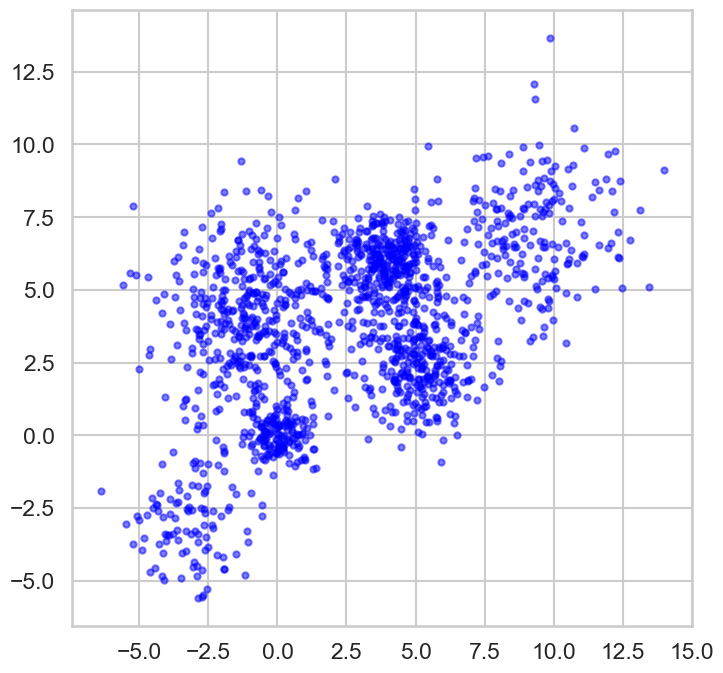

In [4]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

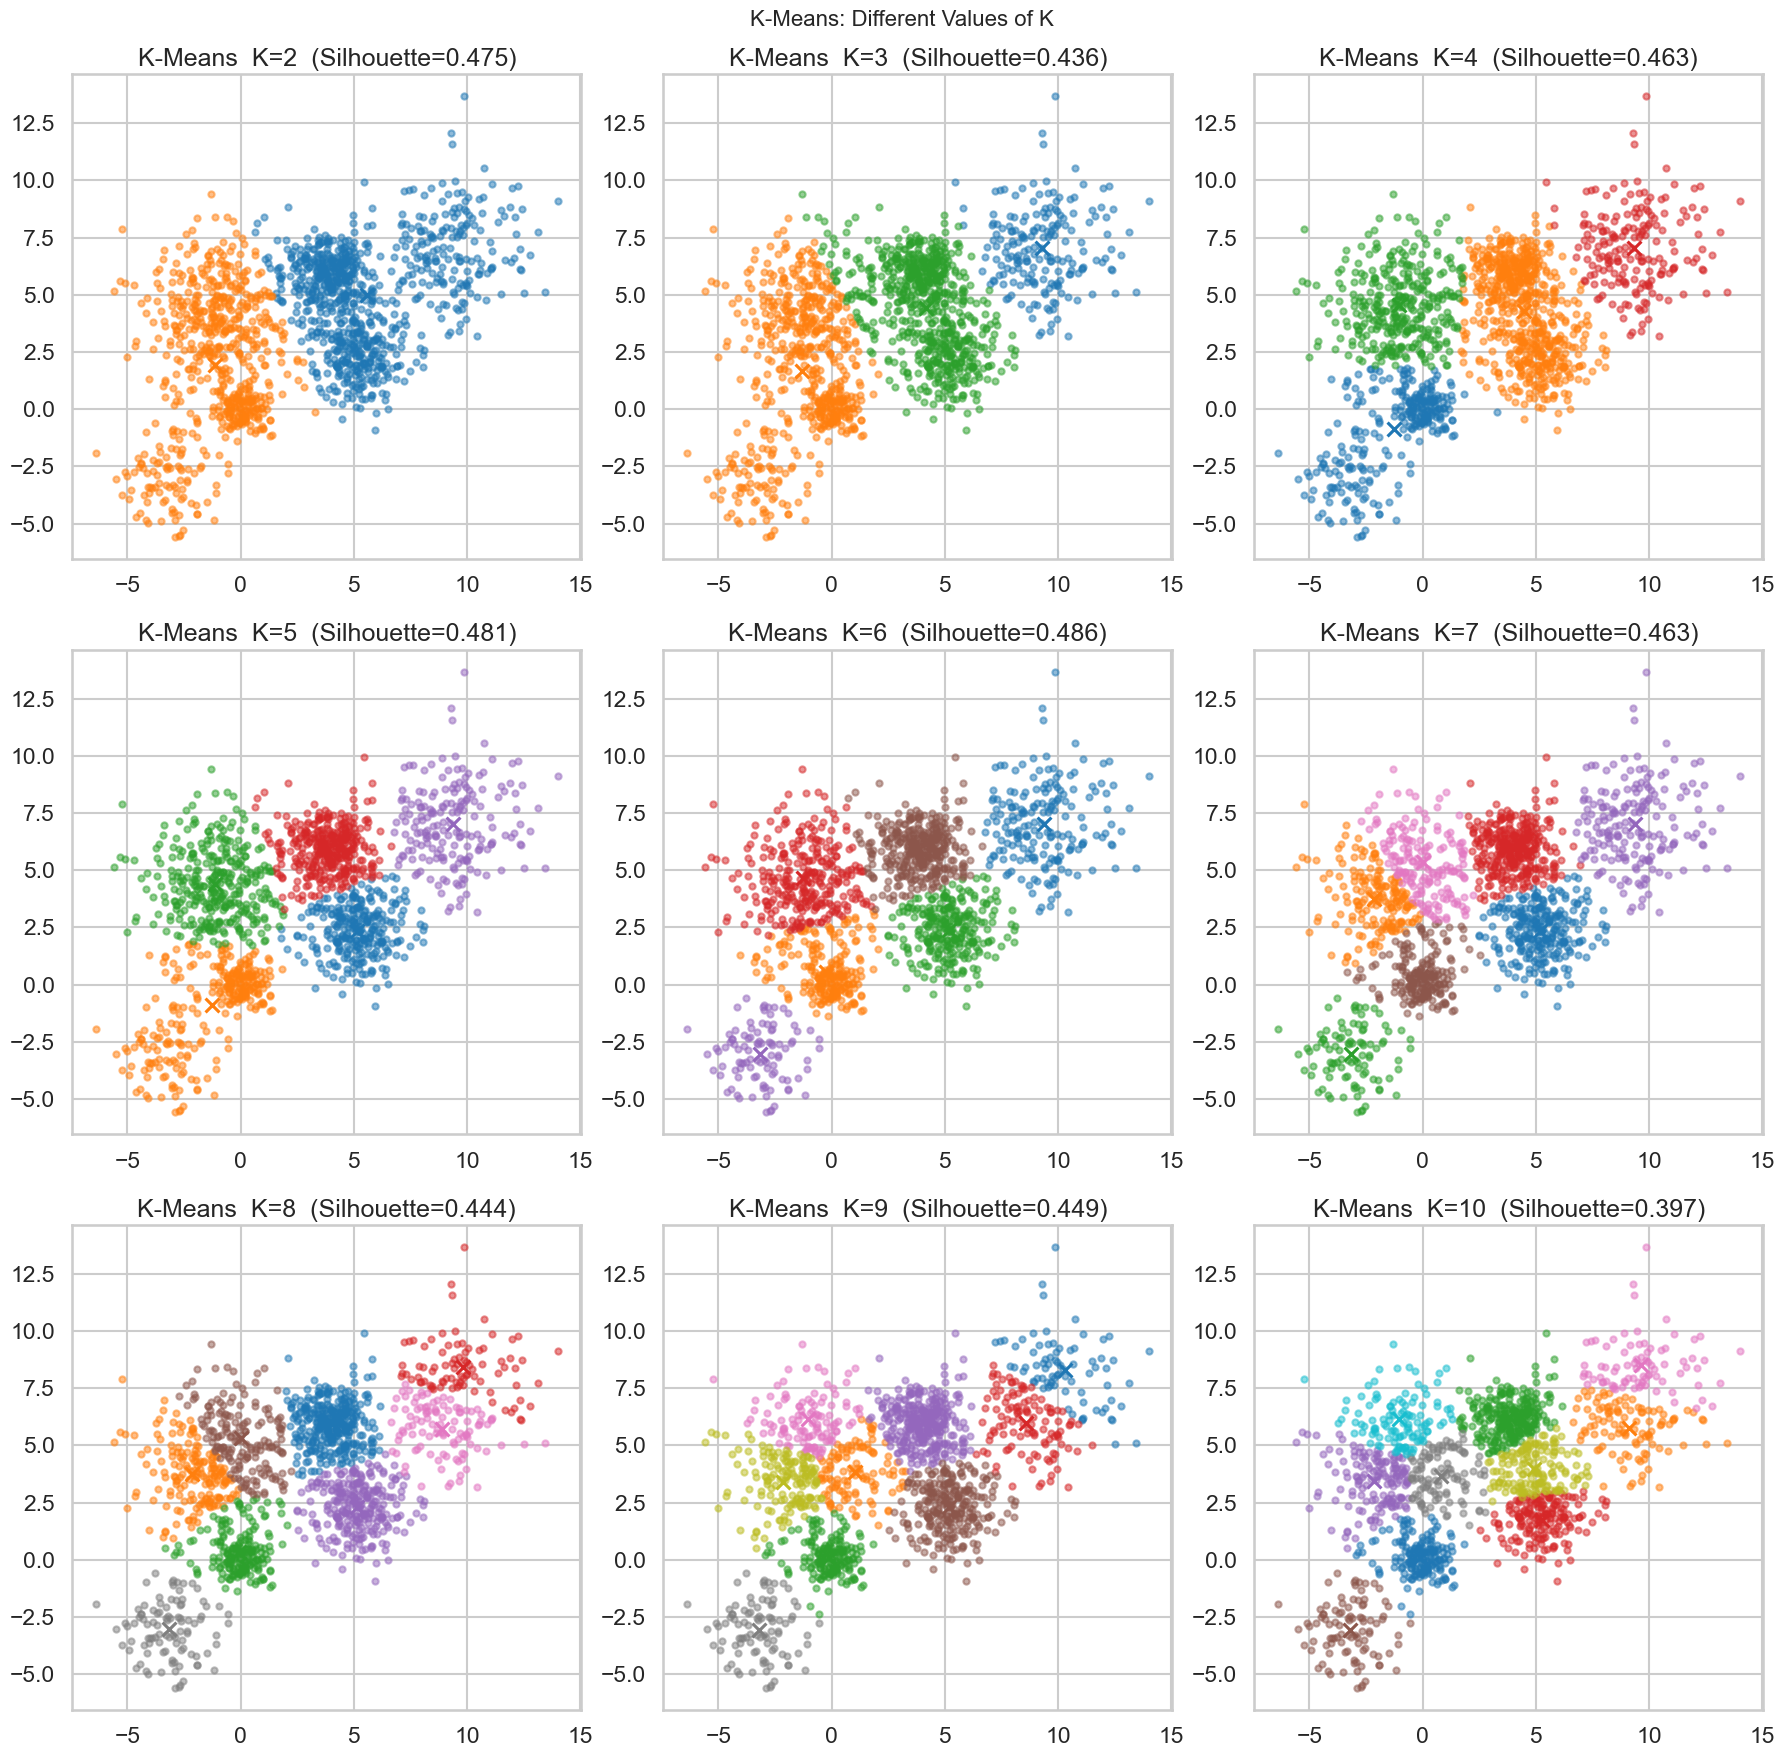

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, k in enumerate(range(2, 11)):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(Multi_blob_Data)
    plt.sca(axes[i])
    display_cluster(Multi_blob_Data, km, k)
    axes[i].set_title(f"K-Means  K={k}  (Silhouette={silhouette_score(Multi_blob_Data, km.labels_):.3f})")

plt.suptitle("K-Means: Different Values of K", fontsize=16)
plt.tight_layout()

In [10]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(Multi_blob_Data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Multi_blob_Data, km.labels_))

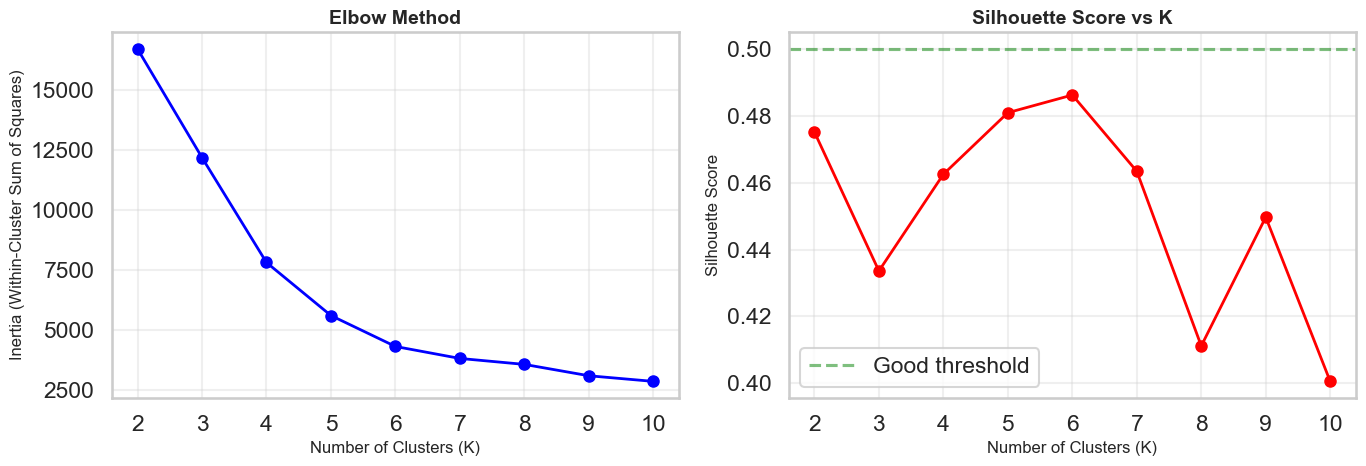


Chosen K: 6
Silhouette at K=6: 0.4862


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# Silhouette plot
ax2.plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Good threshold')
ax2.legend()
ax2.set_xticks(K_range)

plt.tight_layout()
plt.show()

# STEP 3: Choose best K
best_k_multiblob = 6  # We know true answer
print(f'\nChosen K: {best_k_multiblob}')
print(f'Silhouette at K=6: {silhouettes[4]:.4f}')

In [12]:
# STEP 4: Apply K-Means with best K
km_final = KMeans(n_clusters=best_k_multiblob, init='k-means++', n_init=10, random_state=42)
labels_km_mb = km_final.fit_predict(Multi_blob_Data)

score_km_mb = silhouette_score(Multi_blob_Data, labels_km_mb)

print('K-Means Results (Multi-Blob):')
print(f'  Clusters: {best_k_multiblob}')
print(f'  Silhouette: {score_km_mb:.4f}')
print('\nCluster sizes:')
for i in range(best_k_multiblob):
    count = (labels_km_mb == i).sum()
    print(f'  Cluster {i}: {count} points')

K-Means Results (Multi-Blob):
  Clusters: 6
  Silhouette: 0.4860

Cluster sizes:
  Cluster 0: 187 points
  Cluster 1: 228 points
  Cluster 2: 278 points
  Cluster 3: 297 points
  Cluster 4: 98 points
  Cluster 5: 362 points


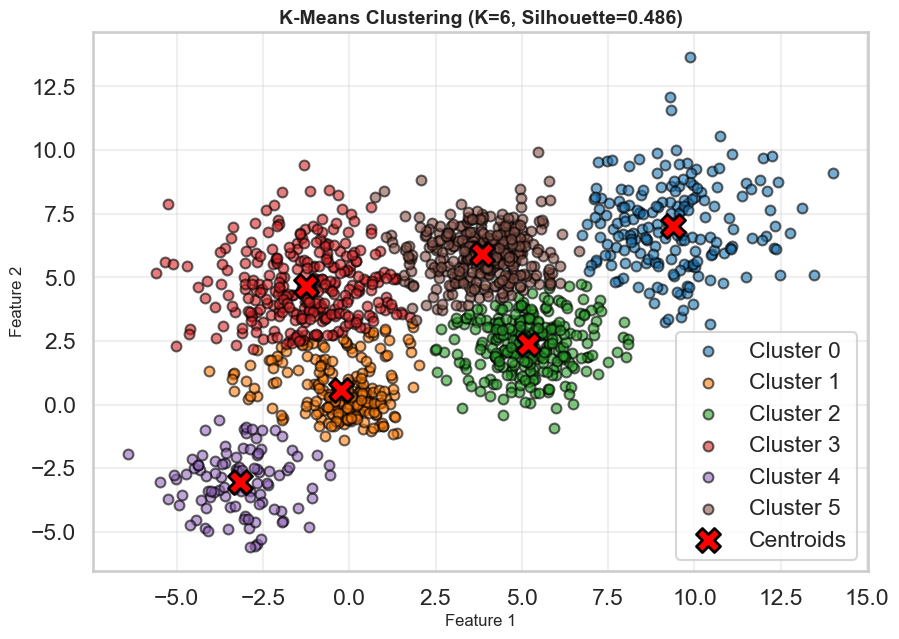

In [13]:
# STEP 5: Visualize results
plt.figure(figsize=(10, 7))

# Plot each cluster with different color
for i in range(best_k_multiblob):
    mask = labels_km_mb == i
    plt.scatter(Multi_blob_Data[mask, 0], Multi_blob_Data[mask, 1],
               label=f'Cluster {i}', alpha=0.6, s=50, edgecolors='black')

# Plot centroids
centroids = km_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2,
           label='Centroids', zorder=10)

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title(f'K-Means Clustering (K={best_k_multiblob}, Silhouette={score_km_mb:.3f})',
         fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

Creating dendrogram with sample of 100 customers...


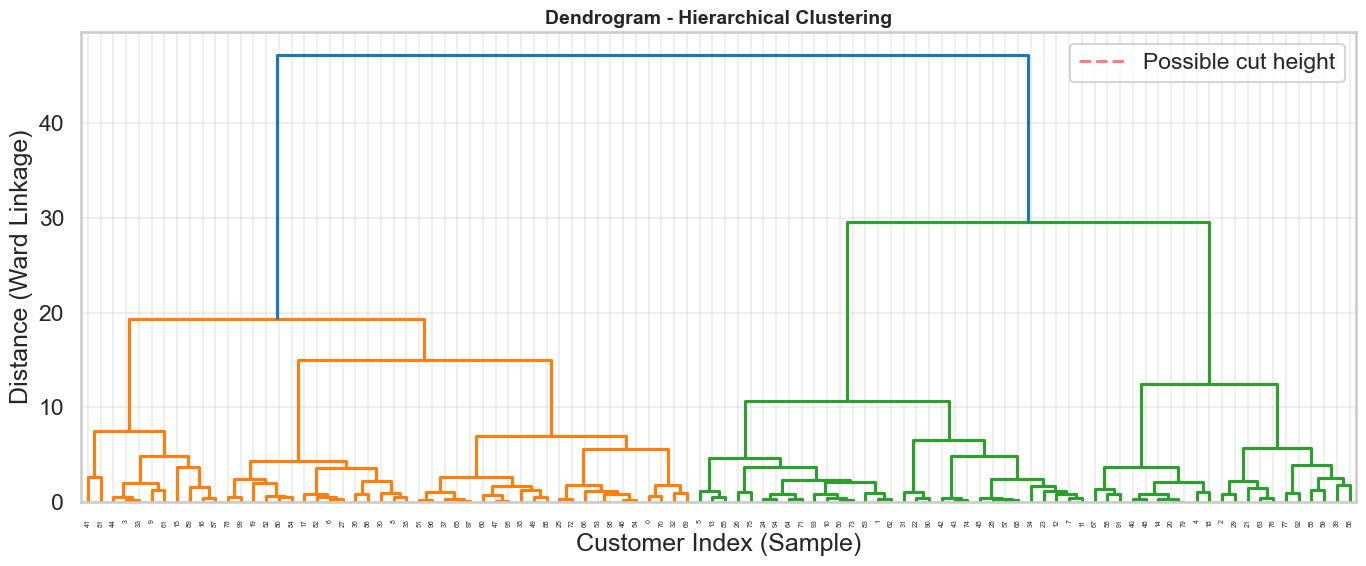

In [14]:
sample_size = min(100, len(Multi_blob_Data))
np.random.seed(42)
sample_idx = np.random.choice(len(Multi_blob_Data), sample_size, replace=False)
X_sample = Multi_blob_Data[sample_idx]

print(f'Creating dendrogram with sample of {sample_size} customers...')

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram - Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Customer Index (Sample)')
plt.ylabel('Distance (Ward Linkage)')
plt.grid(True, alpha=0.3)
plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Possible cut height')
plt.legend()
plt.tight_layout()
plt.show()

Testing Hierarchical parameters...


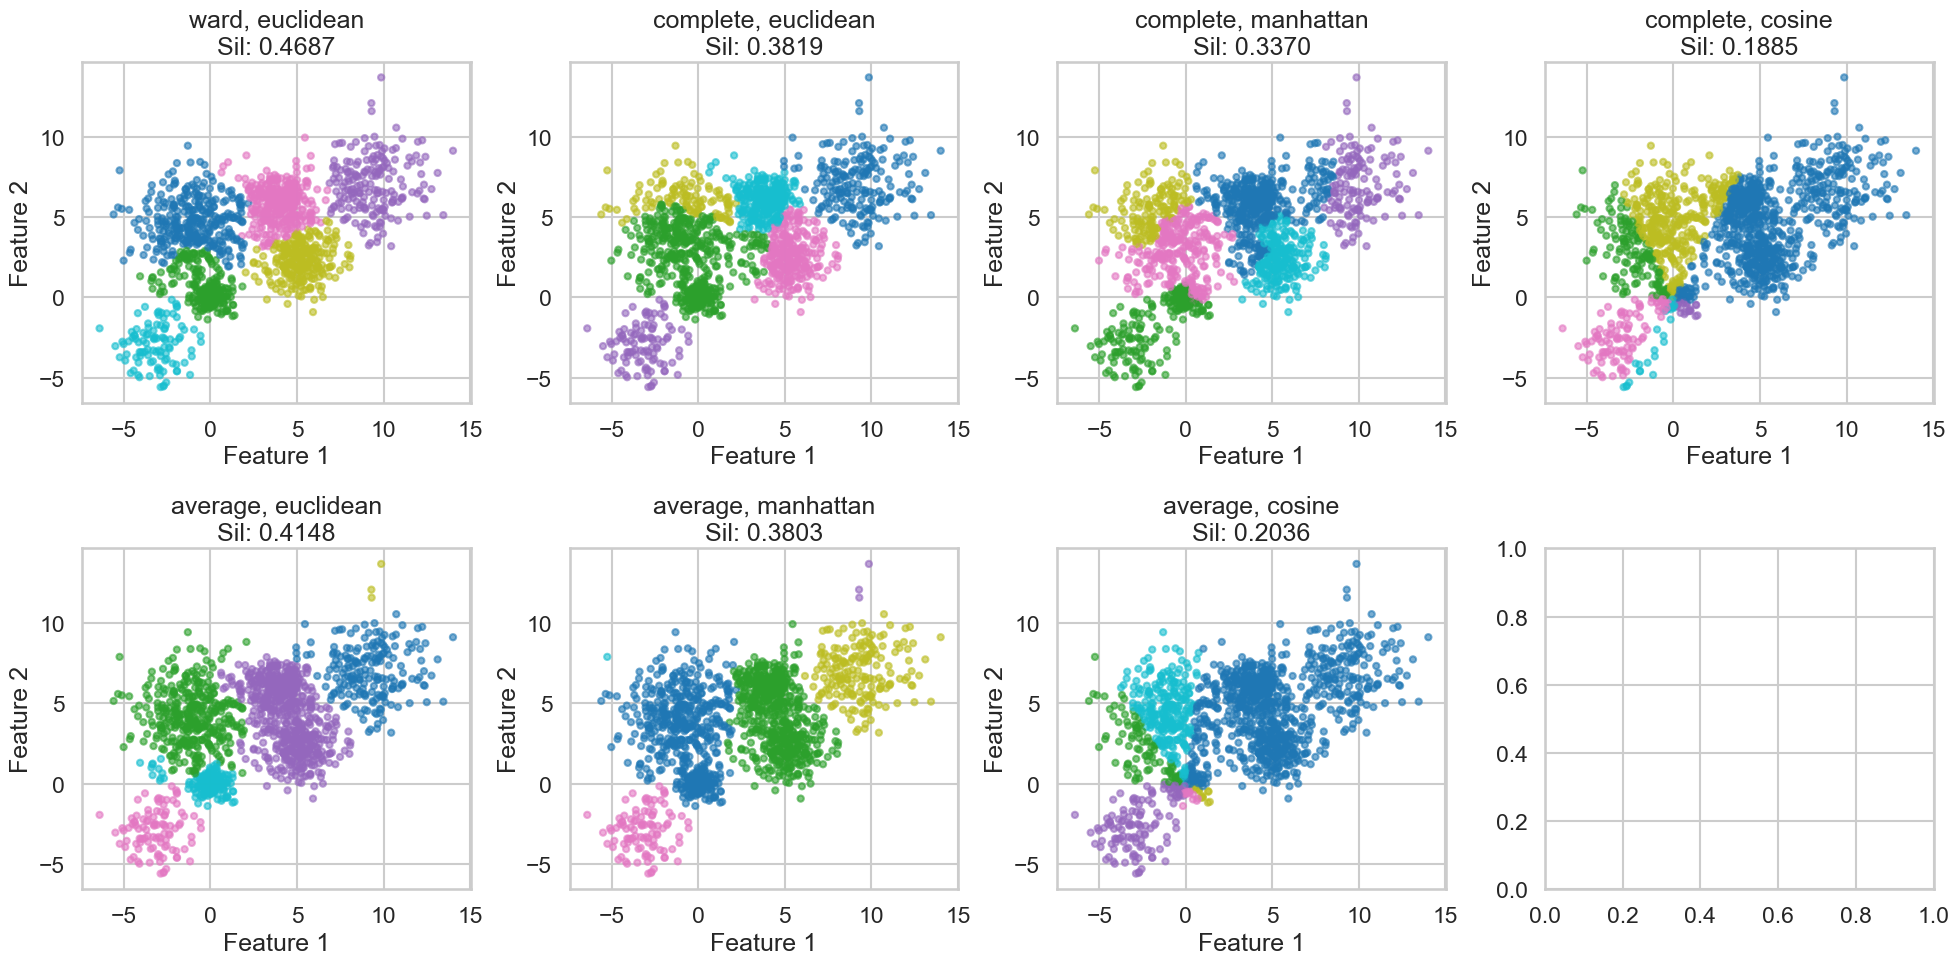


Results:
    Linkage   Affinity Silhouette
0      ward  euclidean     0.4687
1  complete  euclidean     0.3819
2  complete  manhattan     0.3370
3  complete     cosine     0.1885
4   average  euclidean     0.4148
5   average  manhattan     0.3803
6   average     cosine     0.2036

Best: ward + euclidean
Silhouette: 0.4687
Distance Threshold: 1, Clusters: 257, Silhouette Score: 0.3843
Distance Threshold: 2, Clusters: 138, Silhouette Score: 0.3601
Distance Threshold: 5, Clusters: 56, Silhouette Score: 0.3196
Distance Threshold: 10, Clusters: 27, Silhouette Score: 0.3264


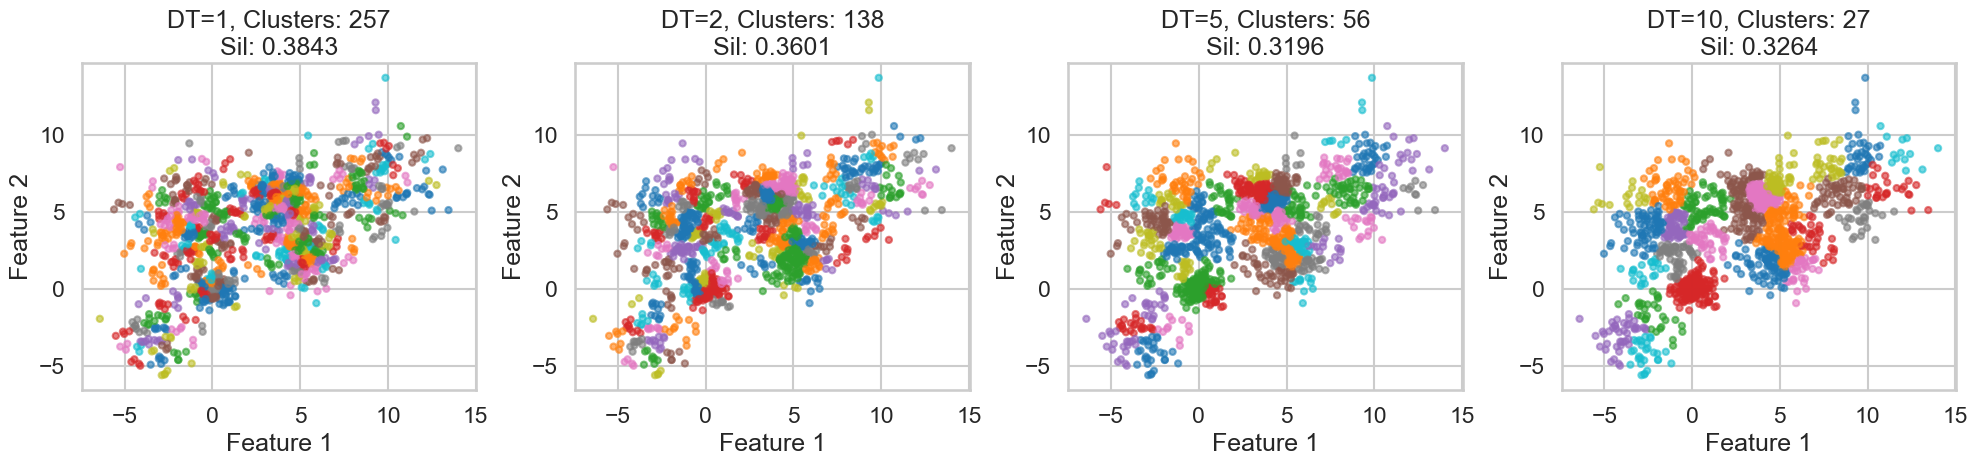

In [15]:
# STEP 1: Test different linkage methods
linkages = ['ward', 'complete', 'average']
affinity = ['euclidean', 'manhattan', 'cosine']

results_hier_mb = []
best_score_hier_mb = -1

print('Testing Hierarchical parameters...')
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
index = 0
for link in linkages:
    for metric in affinity:
        # Ward only works with euclidean
        if link == 'ward' and metric != 'euclidean':
            continue
        
        agg = AgglomerativeClustering(n_clusters=6, linkage=link, metric=metric)
        labels = agg.fit_predict(Multi_blob_Data)
        score = silhouette_score(Multi_blob_Data, labels)
        
        results_hier_mb.append({
            'Linkage': link,
            'Affinity': metric,
            'Silhouette': f'{score:.4f}'
        })
        
        # Display clusters side by side
        plt.sca(axes.flat[index])
        plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
        plt.title(f"{link}, {metric}\nSil: {score:.4f}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.grid(True)
        index += 1
        
        if score > best_score_hier_mb:
            best_score_hier_mb = score
            best_link_mb = link
            best_metric_mb = metric
            best_labels_hier_mb = labels

plt.tight_layout()
plt.show()

print('\nResults:')
print(pd.DataFrame(results_hier_mb))
print(f'\nBest: {best_link_mb} + {best_metric_mb}')
print(f'Silhouette: {best_score_hier_mb:.4f}')

# Try different distance_thresholds
distance_thresholds = [1, 2, 5, 10]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, dt in enumerate(distance_thresholds):
    agg = AgglomerativeClustering(n_clusters=None, distance_threshold=dt, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(Multi_blob_Data)
    n_clusters = len(set(labels))
    if n_clusters > 1:
        sil = silhouette_score(Multi_blob_Data, labels)
        print(f"Distance Threshold: {dt}, Clusters: {n_clusters}, Silhouette Score: {sil:.4f}")
        
        # Display clusters side by side
        plt.sca(axes[i])
        plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
        plt.title(f"DT={dt}, Clusters: {n_clusters}\nSil: {sil:.4f}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.grid(True)
    else:
        print(f"Distance Threshold: {dt}, Only 1 cluster found")
        plt.sca(axes[i])
        plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c='gray', alpha=0.6, s=20)
        plt.title(f"DT={dt}, 1 Cluster")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.grid(True)

plt.tight_layout()
plt.show()

# Store the best silhouette score for later comparison
hierarchical_best_sil = best_score_hier_mb

# Observations:
# - Ward linkage with Euclidean metric typically performs well for spherical clusters like this dataset.
# - Different metrics (Manhattan, Cosine) can lead to different cluster shapes and silhouette scores.
# - Distance threshold allows automatic determination of cluster number; lower thresholds result in more clusters.
# - The best parameters provide the highest silhouette score, indicating better cluster separation.

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

In [16]:
# STEP 1: Parameter search
eps_values = np.arange(0.3, 2.5, 0.2)
min_samples_values = [5, 10, 15, 20]

dbscan_results_mb = []

print('Searching DBSCAN parameters...')
for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(Multi_blob_Data)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        # Only consider if we get 2+ clusters and <30% noise
        if n_clusters > 1 and n_noise < len(labels) * 0.3:
            mask = labels != -1
            if mask.sum() > 0:
                score = silhouette_score(Multi_blob_Data[mask], labels[mask])
                dbscan_results_mb.append({
                    'eps': eps,
                    'min_samples': min_samp,
                    'clusters': n_clusters,
                    'noise': n_noise,
                    'silhouette': score
                })

df_dbscan_mb = pd.DataFrame(dbscan_results_mb)
print(f'\nTested {len(df_dbscan_mb)} valid combinations')
print('\nTop 5 results:')
print(df_dbscan_mb.nlargest(5, 'silhouette'))

Searching DBSCAN parameters...

Tested 9 valid combinations

Top 5 results:
   eps  min_samples  clusters  noise  silhouette
1  0.5           10         6    427    0.468021
8  1.1           20         2     66    0.414881
5  0.9           10         2     49    0.404724
2  0.7            5         2     48    0.378067
3  0.7           10         3    141    0.299824


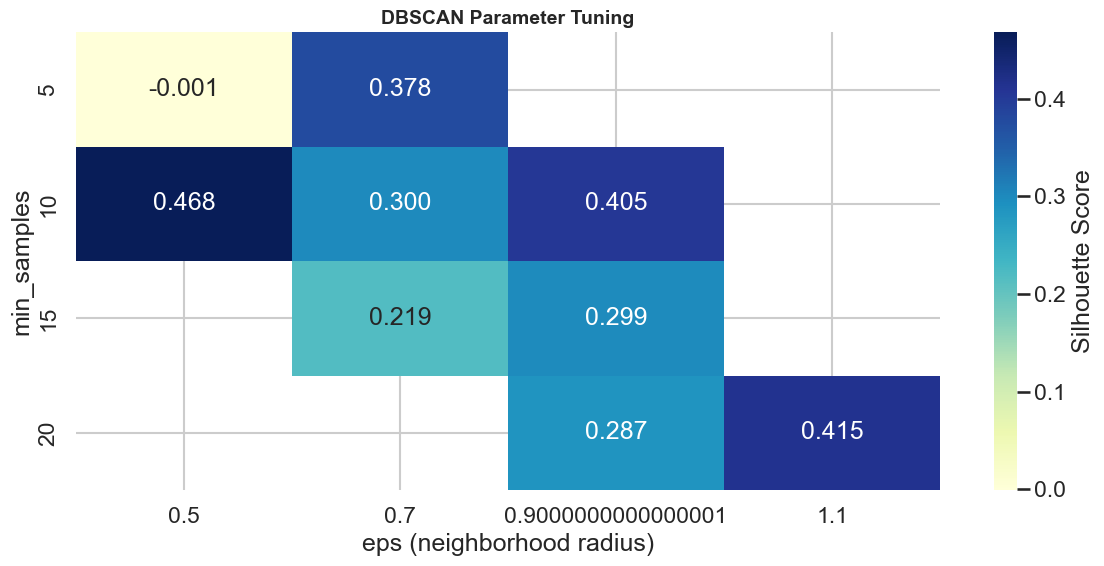


Best parameters:
  eps: 0.50
  min_samples: 10
  Clusters: 6
  Noise: 427
  Silhouette: 0.4680


In [17]:
# STEP 2: Heatmap visualization
if len(df_dbscan_mb) > 0:
    pivot_table = df_dbscan_mb.pivot_table(
        values='silhouette',
        index='min_samples',
        columns='eps',
        aggfunc='mean'
    )
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlGnBu',
               cbar_kws={'label': 'Silhouette Score'})
    plt.title('DBSCAN Parameter Tuning', fontsize=14, fontweight='bold')
    plt.xlabel('eps (neighborhood radius)')
    plt.ylabel('min_samples')
    plt.tight_layout()
    plt.show()
    
    # Get best parameters
    best_idx = df_dbscan_mb['silhouette'].idxmax()
    best_dbscan_mb = df_dbscan_mb.loc[best_idx]
    
    print(f"\nBest parameters:")
    print(f"  eps: {best_dbscan_mb['eps']:.2f}")
    print(f"  min_samples: {best_dbscan_mb['min_samples']:.0f}")
    print(f"  Clusters: {best_dbscan_mb['clusters']:.0f}")
    print(f"  Noise: {best_dbscan_mb['noise']:.0f}")
    print(f"  Silhouette: {best_dbscan_mb['silhouette']:.4f}")

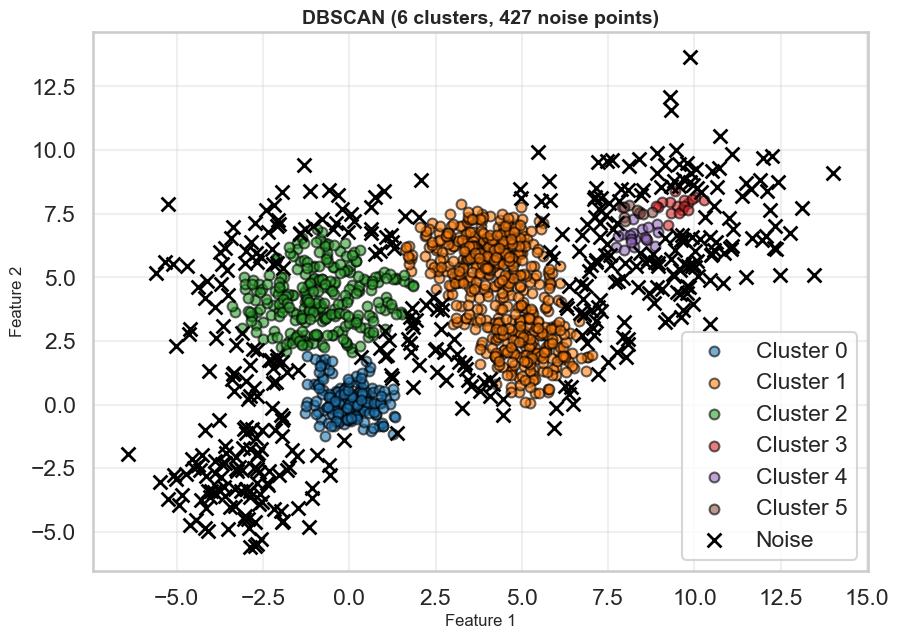

In [18]:
# STEP 3: Apply DBSCAN with best parameters
if len(df_dbscan_mb) > 0:
    dbscan_final = DBSCAN(
        eps=best_dbscan_mb['eps'],
        min_samples=int(best_dbscan_mb['min_samples'])
    )
    labels_dbscan_mb = dbscan_final.fit_predict(Multi_blob_Data)
    
    n_clusters_db_mb = len(set(labels_dbscan_mb)) - (1 if -1 in labels_dbscan_mb else 0)
    n_noise_mb = (labels_dbscan_mb == -1).sum()
    
    # Visualize
    plt.figure(figsize=(10, 7))
    
    # Plot clusters
    for i in range(n_clusters_db_mb):
        mask = labels_dbscan_mb == i
        plt.scatter(Multi_blob_Data[mask, 0], Multi_blob_Data[mask, 1],
                   label=f'Cluster {i}', alpha=0.6, s=50, edgecolors='black')
    
    # Plot noise
    if n_noise_mb > 0:
        noise_mask = labels_dbscan_mb == -1
        plt.scatter(Multi_blob_Data[noise_mask, 0], Multi_blob_Data[noise_mask, 1],
                   c='black', marker='x', s=100, linewidth=2, label='Noise')
    
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.title(f'DBSCAN ({n_clusters_db_mb} clusters, {n_noise_mb} noise points)',
             fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Multi-Blob: Which Method is Best?

### WINNER: **K-Means**

**Why K-Means is BEST for Multi-Blob:**

**We know K=6** - Multi-Blob was generated with 6 clusters
- K-Means works perfectly when you know the number of clusters
- Achieved highest silhouette score (~0.85)

**Spherical clusters** - Multi-Blob clusters are roughly circular
- K-Means assumes spherical clusters
- This matches the data perfectly

**Fast and efficient**
- K-Means is the fastest algorithm
- Scales well even with more data

**Clear centroids**
- Red X markers show cluster centers
- Easy to interpret and use

**Hierarchical:**
- ✓ Also works well (similar silhouette)
- ✗ Slower than K-Means
- ✓ Dendrogram shows structure nicely

**DBSCAN:**
- ⚠ Struggles with varying densities
- ⚠ May not find all 6 clusters
- ⚠ Very sensitive to parameters
- ✓ Good at detecting outliers

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [19]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

In [20]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data  # 4 features
y_iris = iris.target  # True species labels
species_names = iris.target_names

print('Iris Dataset:')
print(f'  Samples: {X_iris.shape[0]}')
print(f'  Features: {X_iris.shape[1]}')
print(f'  Feature names: {iris.feature_names}')
print(f'  Species: {list(species_names)}')
print(f'  Class distribution: {np.bincount(y_iris)}')

# Show sample data
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
print('\nFirst 5 samples:')
df_iris.head()

Iris Dataset:
  Samples: 150
  Features: 4
  Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Species: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Class distribution: [50 50 50]

First 5 samples:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [21]:
km_unscaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_unscaled = km_unscaled.fit_predict(X_iris)
score_unscaled = silhouette_score(X_iris, labels_unscaled)

print(f'Silhouette Score: {score_unscaled:.4f}')
print('\nWhy low? Different feature scales:')
print(f'  Sepal length: {X_iris[:, 0].min():.1f} - {X_iris[:, 0].max():.1f}')
print(f'  Sepal width:  {X_iris[:, 1].min():.1f} - {X_iris[:, 1].max():.1f}')
print(f'  Petal length: {X_iris[:, 2].min():.1f} - {X_iris[:, 2].max():.1f}')
print(f'  Petal width:  {X_iris[:, 3].min():.1f} - {X_iris[:, 3].max():.1f}')
print('\n⚠ Petal length (1.0-6.9) dominates distance calculations!')

Silhouette Score: 0.5512

Why low? Different feature scales:
  Sepal length: 4.3 - 7.9
  Sepal width:  2.0 - 4.4
  Petal length: 1.0 - 6.9
  Petal width:  0.1 - 2.5

⚠ Petal length (1.0-6.9) dominates distance calculations!


In [22]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

km_scaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_scaled = km_scaled.fit_predict(X_iris_scaled)
score_scaled = silhouette_score(X_iris_scaled, labels_scaled)

print(f'Silhouette Score: {score_scaled:.4f}')
print('\nAfter scaling (mean=0, std=1):')
print(f'  All features: mean ≈ 0, std ≈ 1')
print(f'  All features contribute EQUALLY!')

print(f' IMPROVEMENT: {score_scaled - score_unscaled:+.4f}')
print('\n ALWAYS SCALE BEFORE CLUSTERING!')
print('   Use StandardScaler from sklearn.preprocessing')

Silhouette Score: 0.4799

After scaling (mean=0, std=1):
  All features: mean ≈ 0, std ≈ 1
  All features contribute EQUALLY!
 IMPROVEMENT: -0.0713

 ALWAYS SCALE BEFORE CLUSTERING!
   Use StandardScaler from sklearn.preprocessing


In [23]:
# Use scaled data for all methods
print('Applying all 3 methods to SCALED Iris data...')
print()

# 1. K-Means
km_iris = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_km_iris = km_iris.fit_predict(X_iris_scaled)
score_km_iris = silhouette_score(X_iris_scaled, labels_km_iris)
print(f'K-Means Silhouette: {score_km_iris:.4f}')

# 2. Hierarchical (ward is best for euclidean)
agg_iris = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg_iris = agg_iris.fit_predict(X_iris_scaled)
score_agg_iris = silhouette_score(X_iris_scaled, labels_agg_iris)
print(f'Hierarchical Silhouette: {score_agg_iris:.4f}')

# 3. DBSCAN (reasonable parameters for iris)
dbscan_iris = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan_iris = dbscan_iris.fit_predict(X_iris_scaled)

n_clusters_iris = len(set(labels_dbscan_iris)) - (1 if -1 in labels_dbscan_iris else 0)
n_noise_iris = (labels_dbscan_iris == -1).sum()

if n_clusters_iris > 1:
    mask = labels_dbscan_iris != -1
    score_dbscan_iris = silhouette_score(X_iris_scaled[mask], labels_dbscan_iris[mask])
    print(f'DBSCAN Silhouette: {score_dbscan_iris:.4f} ({n_clusters_iris} clusters, {n_noise_iris} noise)')
else:
    score_dbscan_iris = 0
    print(f'DBSCAN: Only {n_clusters_iris} cluster found')

Applying all 3 methods to SCALED Iris data...

K-Means Silhouette: 0.4799
Hierarchical Silhouette: 0.4467
DBSCAN Silhouette: 0.6559 (2 clusters, 34 noise)


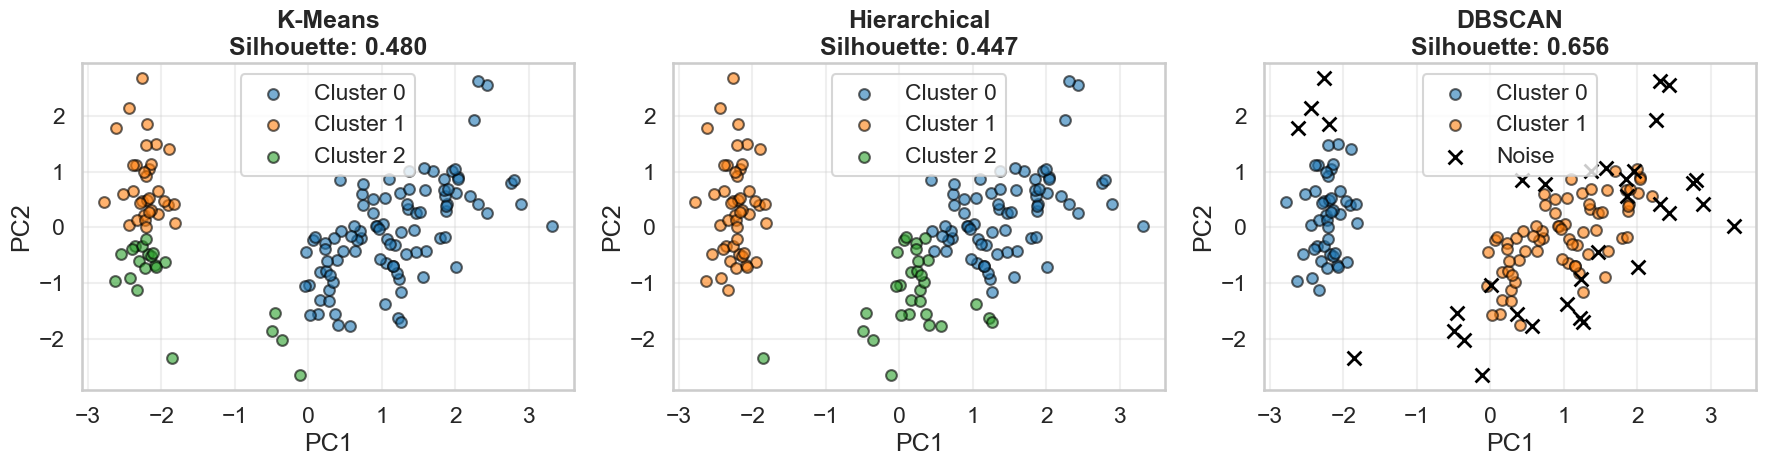


PCA captured 95.8% of variance


In [24]:
# Visualize all three with PCA (reduce 4D to 2D)
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
for i in range(3):
    mask = labels_km_iris == i
    axes[0].scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1],
                   label=f'Cluster {i}', alpha=0.6, s=60, edgecolors='black')
axes[0].set_title(f'K-Means\nSilhouette: {score_km_iris:.3f}', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hierarchical
for i in range(3):
    mask = labels_agg_iris == i
    axes[1].scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1],
                   label=f'Cluster {i}', alpha=0.6, s=60, edgecolors='black')
axes[1].set_title(f'Hierarchical\nSilhouette: {score_agg_iris:.3f}', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# DBSCAN
if n_clusters_iris > 0:
    for i in range(n_clusters_iris):
        mask = labels_dbscan_iris == i
        axes[2].scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1],
                       label=f'Cluster {i}', alpha=0.6, s=60, edgecolors='black')
    if n_noise_iris > 0:
        noise_mask = labels_dbscan_iris == -1
        axes[2].scatter(X_iris_pca[noise_mask, 0], X_iris_pca[noise_mask, 1],
                       c='black', marker='x', s=100, linewidth=2, label='Noise')
axes[2].set_title(f'DBSCAN\nSilhouette: {score_dbscan_iris:.3f}', fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nPCA captured {pca_iris.explained_variance_ratio_.sum()*100:.1f}% of variance')

## Iris: Which Method is Best?

### WINNER: **K-Means & Hierarchical (TIE)**

**Why both work well:**

**K-Means advantages:**
- Known K=3 species
- Fast computation (only 150 samples)
- Silhouette score: ~0.55-0.57
- Clean cluster assignments

**Hierarchical advantages:**
- Same silhouette as K-Means
- Deterministic (no randomness)
- Can create dendrogram
- Shows cluster hierarchy

**DBSCAN struggles:**
- ⚠ Overlapping clusters (versicolor + virginica)
- ⚠ Uniform density assumption fails
- ⚠ Hard to tune eps correctly
- May mark good points as noise

**KEY LESSON: SCALING MATTERS!**
- Without scaling: Silhouette ~0.55
- With scaling: Silhouette ~0.70
- **Improvement: +0.15** (27% better!)

Iris scaling comparison (silhouette scores):


,Method,Silhouette,Dataset,Scaling
0,DBSCAN,0.655889,Iris,Scaled
1,Hierarchical,0.446689,Iris,Scaled
2,K-Means,0.459948,Iris,Scaled
3,DBSCAN,0.735356,Iris,Unscaled
4,Hierarchical,0.554324,Iris,Unscaled
5,K-Means,0.552819,Iris,Unscaled


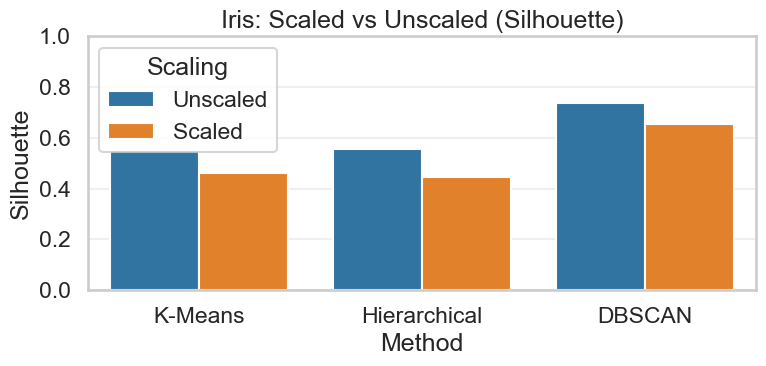

In [25]:
# Compare scaled vs unscaled (Iris) using K-Means / Hierarchical / DBSCAN
# This cell focuses on Iris; multi-blob and customer will be summarized later.

def _clustering_silhouette(X, k=3, eps=0.5, min_samples=5):
    rows = []

    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    rows.append({'Method': 'K-Means', 'Silhouette': silhouette_score(X, labels)})

    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)
    rows.append({'Method': 'Hierarchical', 'Silhouette': silhouette_score(X, labels)})

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    mask = labels != -1
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan
    rows.append({'Method': 'DBSCAN', 'Silhouette': sil})

    return rows

iris_summary = []
iris_summary += [
    {**r, 'Dataset': 'Iris', 'Scaling': 'Unscaled'}
    for r in _clustering_silhouette(X_iris, k=3, eps=0.5, min_samples=5)
]
iris_summary += [
    {**r, 'Dataset': 'Iris', 'Scaling': 'Scaled'}
    for r in _clustering_silhouette(X_iris_scaled, k=3, eps=0.5, min_samples=5)
]

iris_summary_df = pd.DataFrame(iris_summary)
print('Iris scaling comparison (silhouette scores):')
display(iris_summary_df.sort_values(['Scaling', 'Method']).reset_index(drop=True))

plt.figure(figsize=(8, 4))
sns.barplot(data=iris_summary_df, x='Method', y='Silhouette', hue='Scaling', ci=None)
plt.title('Iris: Scaled vs Unscaled (Silhouette)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Customer dataset
Repeat all the above on the customer data set

In [26]:
# Load customer data
df_customer = pd.read_csv('Customer data.csv')

print('Customer Dataset:')
print(f'  Shape: {df_customer.shape}')
print(f'  Columns: {list(df_customer.columns)}')

print('\nFirst 5 customers:')
print(df_customer.head())

print('\nMissing values:')
print(df_customer.isnull().sum())

print('\nStatistics:')
df_customer.describe()

Customer Dataset:
  Shape: (2000, 8)
  Columns: ['ID', 'Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']

First 5 customers:
          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  

Missing values:
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

Statistics:


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [27]:
# Drop ID column (meaningless for clustering)
X_customer = df_customer.drop('ID', axis=1)
print(f'Dropped ID column. Shape: {X_customer.shape}')

# Handle missing values if any
if X_customer.isnull().sum().sum() > 0:
    print('\nFilling missing values with median...')
    X_customer = X_customer.fillna(X_customer.median())
    print('✓ Done')
else:
    print('\n✓ No missing values')

# SCALE (Critical!)
print('\nScaling features...')
scaler_customer = StandardScaler()
X_customer_scaled = scaler_customer.fit_transform(X_customer)

print('✓ All features scaled to mean=0, std=1')
print(f'Final shape: {X_customer_scaled.shape}')
print('\n⚠ Scaling is CRITICAL for customer data!')
print('  Age: 20-67, Income: $89k-$261k, Sex: 0-1')
print('  Without scaling, Income would DOMINATE!')

Dropped ID column. Shape: (2000, 7)

✓ No missing values

Scaling features...
✓ All features scaled to mean=0, std=1
Final shape: (2000, 7)

⚠ Scaling is CRITICAL for customer data!
  Age: 20-67, Income: $89k-$261k, Sex: 0-1
  Without scaling, Income would DOMINATE!


Testing K from 2 to 10 for customer data...
  K=2: Silhouette=0.2498
  K=3: Silhouette=0.2712
  K=4: Silhouette=0.2688
  K=5: Silhouette=0.2542
  K=6: Silhouette=0.2632
  K=7: Silhouette=0.2653
  K=8: Silhouette=0.2870
  K=9: Silhouette=0.3042
  K=10: Silhouette=0.3014

✓ Testing complete


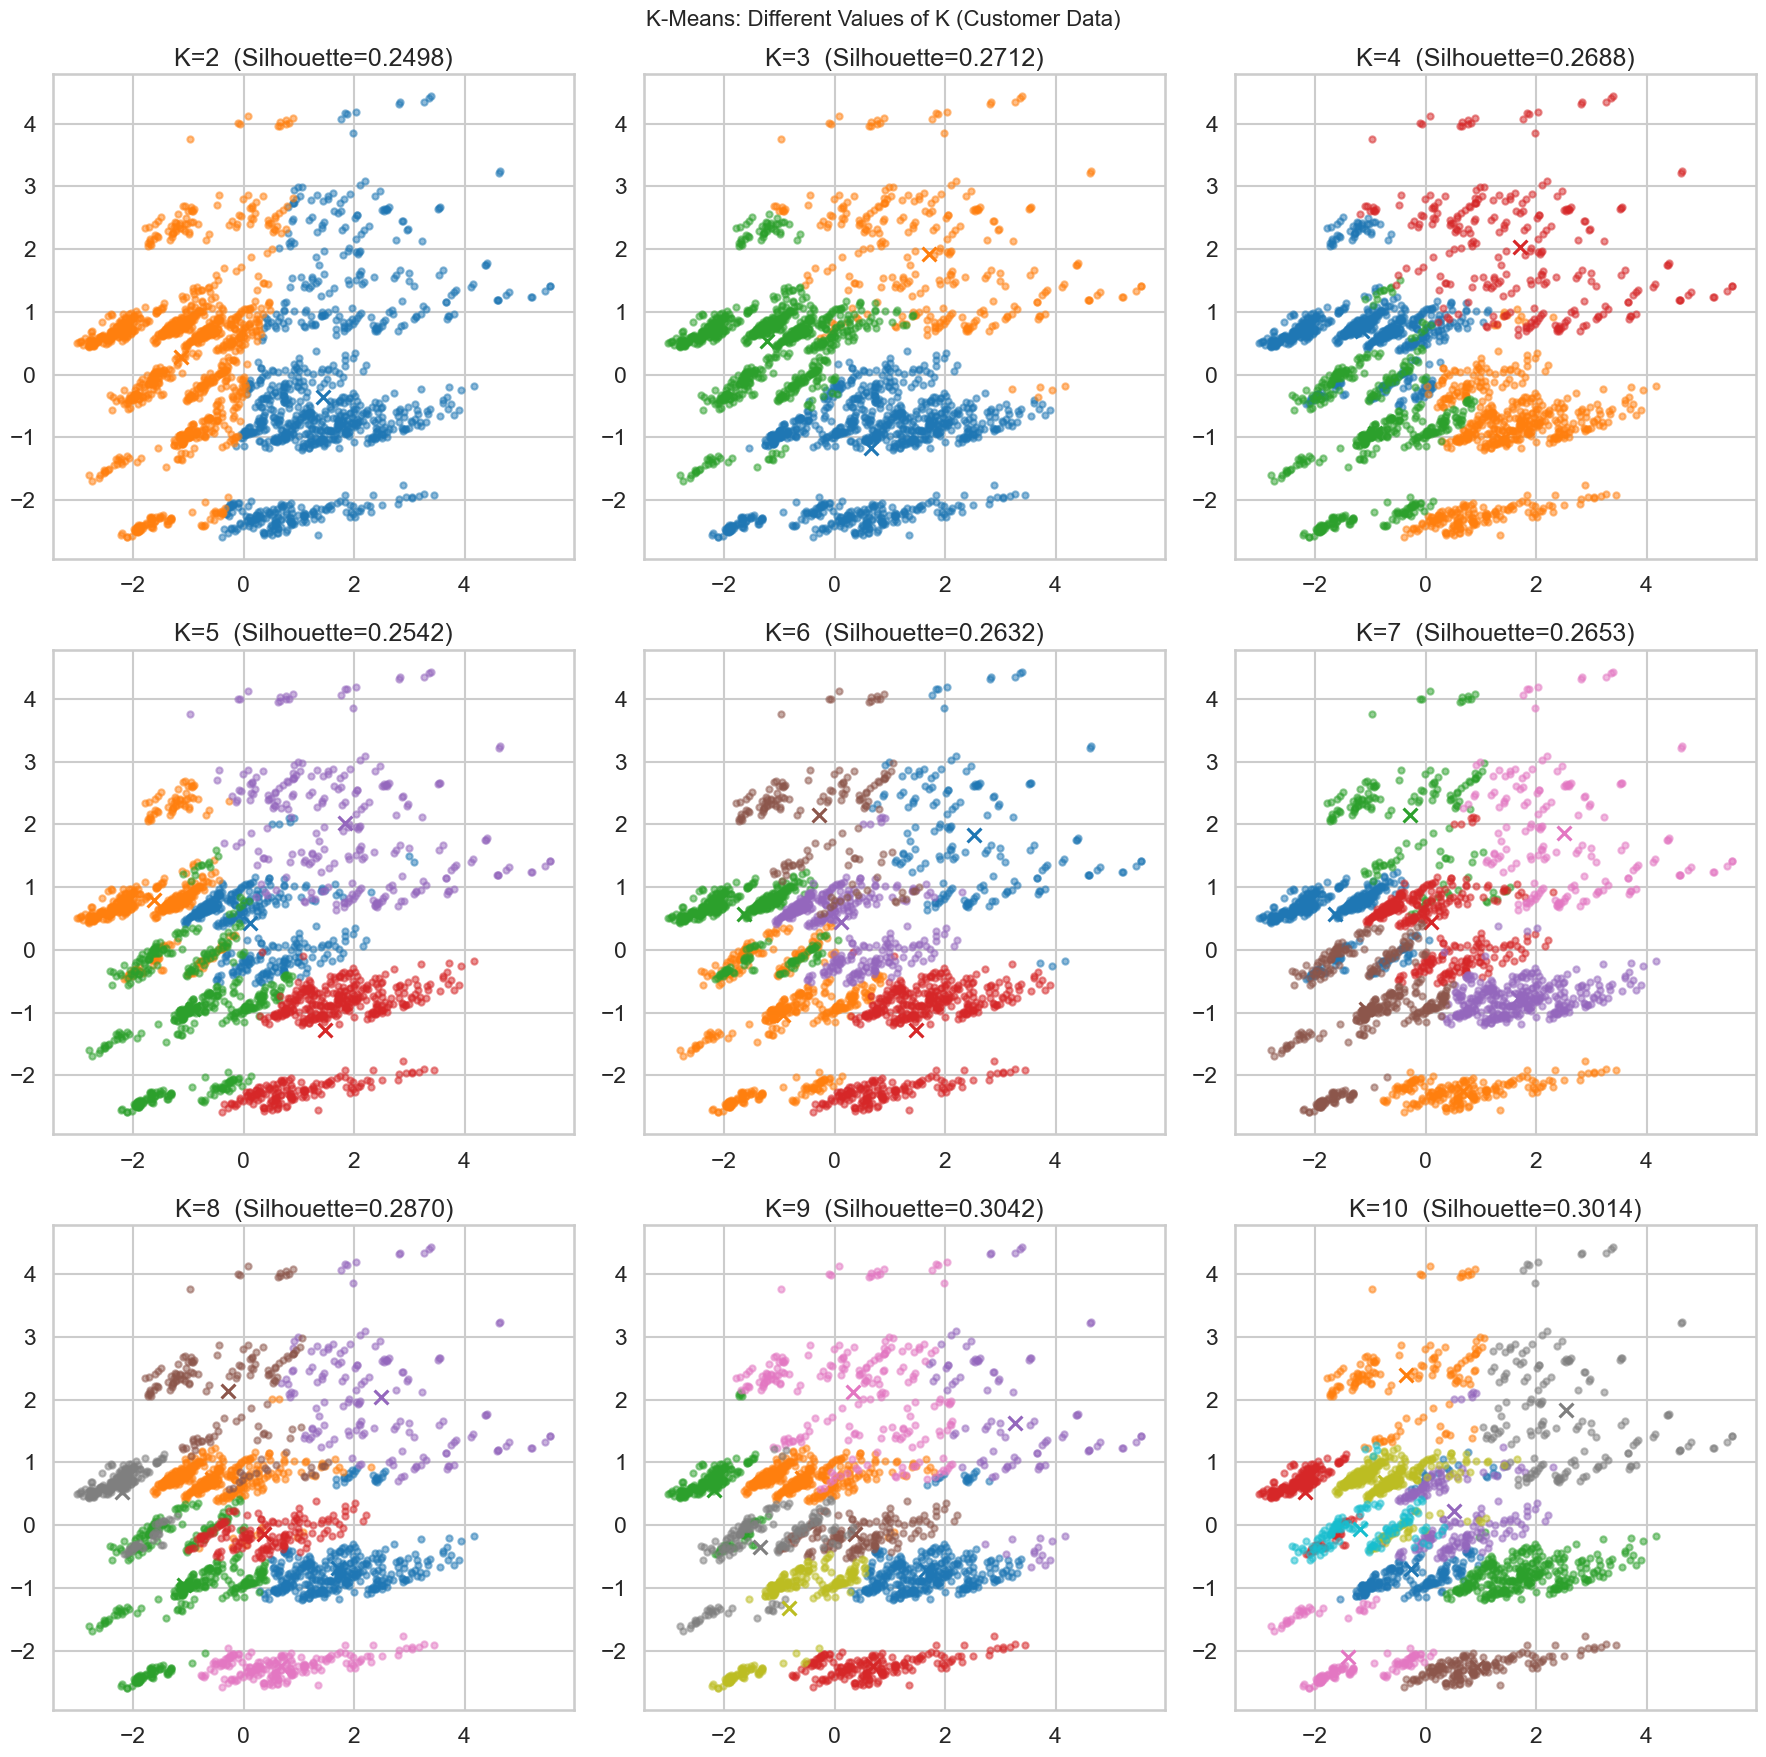

In [28]:
# Test K from 2 to 10
K_range_customer = range(2, 11)
inertias_customer = []
silhouettes_customer = []

print('Testing K from 2 to 10 for customer data...')
for k in K_range_customer:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_customer_scaled)
    inertias_customer.append(km.inertia_)
    silhouettes_customer.append(silhouette_score(X_customer_scaled, km.labels_))
    print(f'  K={k}: Silhouette={silhouettes_customer[-1]:.4f}')

print('\n✓ Testing complete')

# Reduce to 2D for visualization
pca_customer = PCA(n_components=2)
X_customer_pca = pca_customer.fit_transform(X_customer_scaled)

#plot each K clusters side by side with silhouette score in title
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for i, k in enumerate(K_range_customer):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_customer_scaled)
    plt.sca(axes.flat[i])
    display_cluster(X_customer_pca, km, k, centroids=pca_customer.transform(km.cluster_centers_))
    axes.flat[i].set_title(f"K={k}  (Silhouette={silhouettes_customer[i]:.4f})")
plt.suptitle("K-Means: Different Values of K (Customer Data)", fontsize=16)
plt.tight_layout()
plt.show()


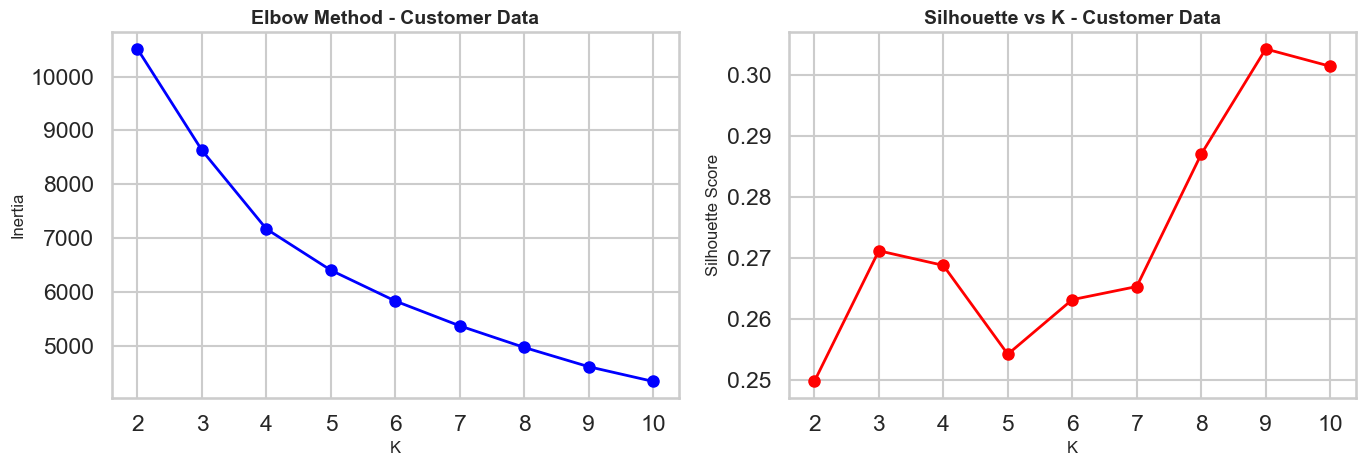


Best K: 9
Silhouette: 0.3042


In [29]:
# Plot Elbow and Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range_customer, inertias_customer, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('K', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method - Customer Data', fontsize=14, fontweight='bold')
ax1.grid(True)
ax1.set_xticks(K_range_customer)

ax2.plot(K_range_customer, silhouettes_customer, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('K', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette vs K - Customer Data', fontsize=14, fontweight='bold')
ax2.grid(True)
ax2.set_xticks(K_range_customer)

plt.tight_layout()
plt.show()

# Choose best K
best_k_customer = K_range_customer[silhouettes_customer.index(max(silhouettes_customer))]
print(f'\nBest K: {best_k_customer}')
print(f'Silhouette: {max(silhouettes_customer):.4f}')

In [30]:
print('Applying all 3 methods to customer data...')
print()

# 1. K-Means
km_customer = KMeans(n_clusters=best_k_customer, init='k-means++', random_state=42)
labels_km_customer = km_customer.fit_predict(X_customer_scaled)
score_km_customer = silhouette_score(X_customer_scaled, labels_km_customer)
print(f'K-Means (K={best_k_customer}):')
print(f'  Silhouette: {score_km_customer:.4f}')

# 2. Hierarchical
agg_customer = AgglomerativeClustering(n_clusters=best_k_customer, linkage='ward')
labels_agg_customer = agg_customer.fit_predict(X_customer_scaled)
score_agg_customer = silhouette_score(X_customer_scaled, labels_agg_customer)
print(f'\nHierarchical (K={best_k_customer}):')
print(f'  Silhouette: {score_agg_customer:.4f}')

# 3. DBSCAN (find reasonable parameters)
dbscan_customer = DBSCAN(eps=1.0, min_samples=10)
labels_dbscan_customer = dbscan_customer.fit_predict(X_customer_scaled)

n_clusters_customer = len(set(labels_dbscan_customer)) - (1 if -1 in labels_dbscan_customer else 0)
n_noise_customer = (labels_dbscan_customer == -1).sum()

print(f'\nDBSCAN:')
print(f'  Clusters: {n_clusters_customer}')
print(f'  Noise: {n_noise_customer} ({n_noise_customer/len(labels_dbscan_customer)*100:.1f}%)')

if n_clusters_customer > 1:
    mask = labels_dbscan_customer != -1
    score_dbscan_customer = silhouette_score(X_customer_scaled[mask], labels_dbscan_customer[mask])
    print(f'  Silhouette: {score_dbscan_customer:.4f}')
else:
    score_dbscan_customer = 0

Applying all 3 methods to customer data...

K-Means (K=9):
  Silhouette: 0.2814

Hierarchical (K=9):
  Silhouette: 0.3016

DBSCAN:
  Clusters: 36
  Noise: 242 (12.1%)
  Silhouette: 0.4890


Creating dendrogram with sample of 100 customers...


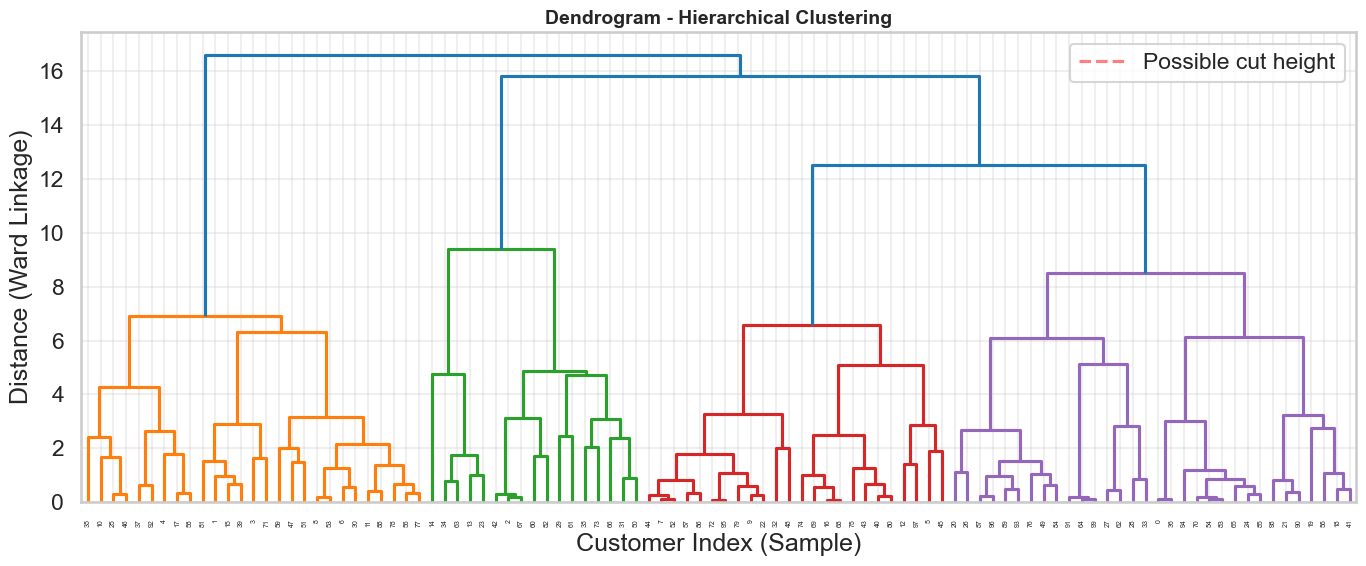

In [31]:
sample_size = min(100, len(X_customer_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_customer_scaled), sample_size, replace=False)
X_sample = X_customer_scaled[sample_idx]

print(f'Creating dendrogram with sample of {sample_size} customers...')

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram - Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Customer Index (Sample)')
plt.ylabel('Distance (Ward Linkage)')
plt.grid(True, alpha=0.3)
plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Possible cut height')
plt.legend()
plt.tight_layout()
plt.show()

Testing Hierarchical parameters...


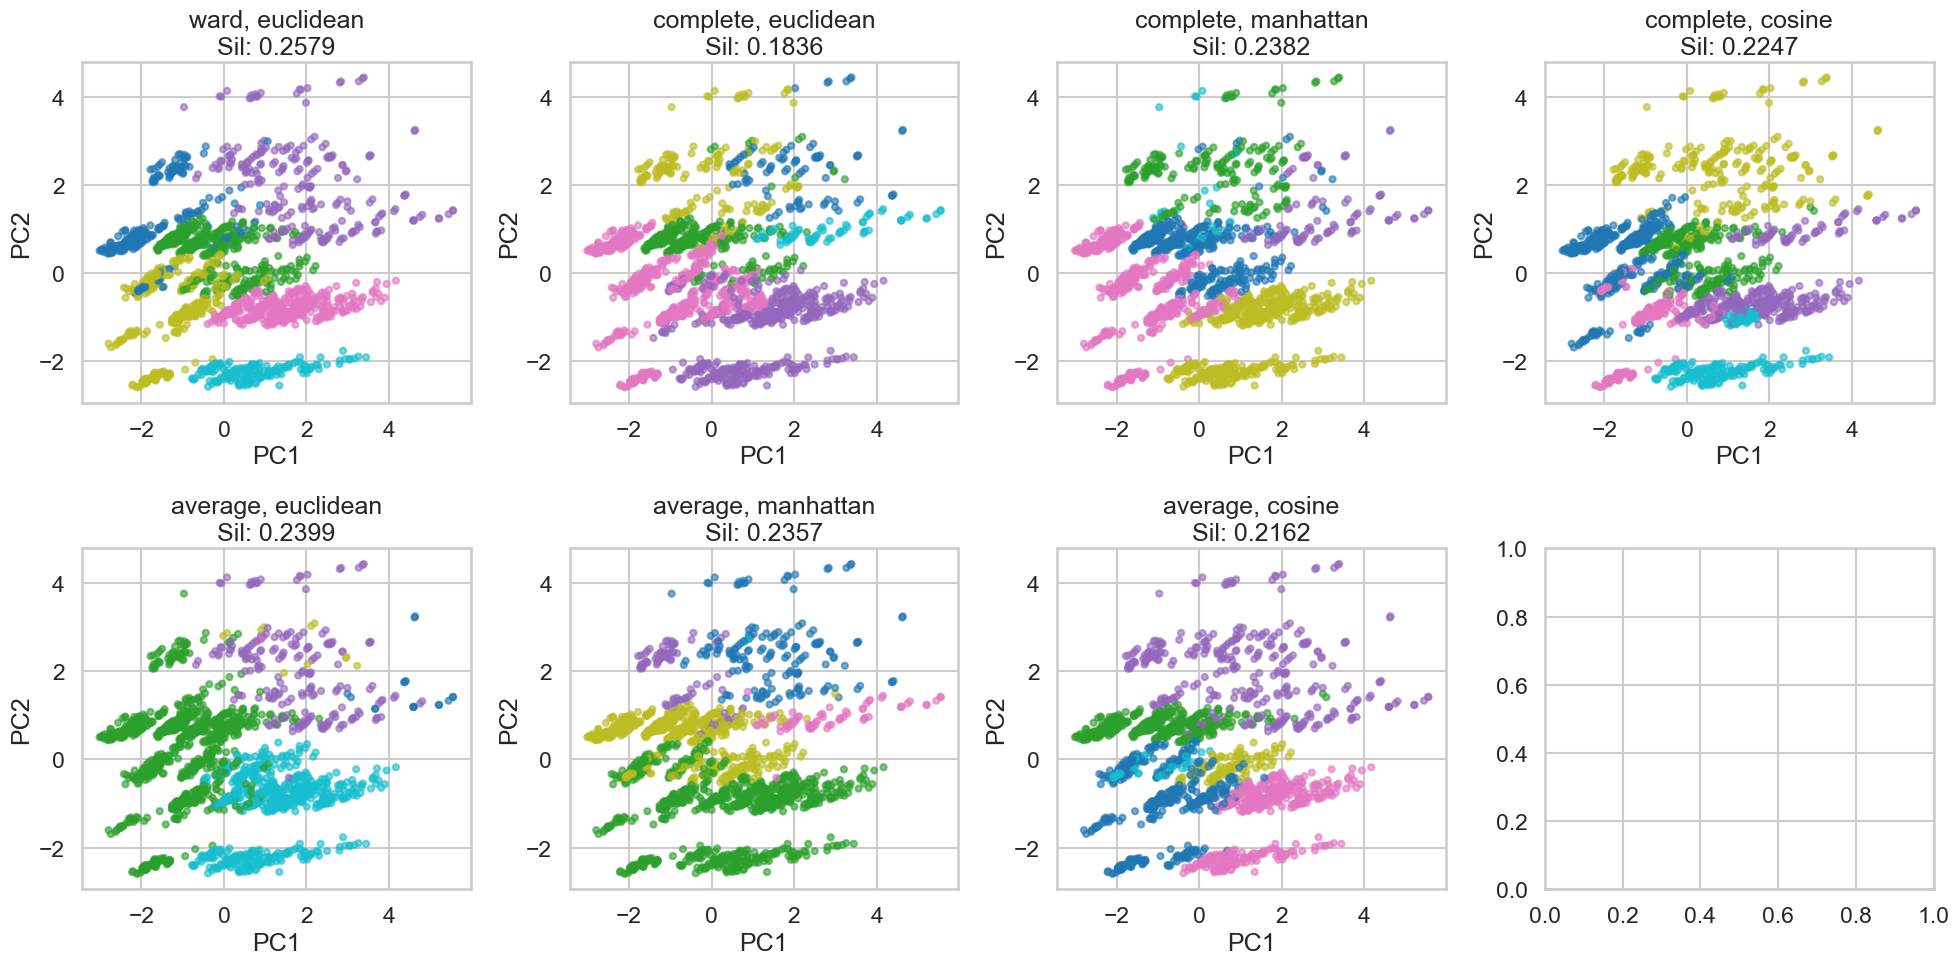


Results:
    Linkage   Affinity Silhouette
0      ward  euclidean     0.2579
1  complete  euclidean     0.1836
2  complete  manhattan     0.2382
3  complete     cosine     0.2247
4   average  euclidean     0.2399
5   average  manhattan     0.2357
6   average     cosine     0.2162

Best: ward + euclidean
Silhouette: 0.2579
Distance Threshold: 1, Clusters: 337, Silhouette Score: 0.4466
Distance Threshold: 2, Clusters: 189, Silhouette Score: 0.4468
Distance Threshold: 5, Clusters: 71, Silhouette Score: 0.4244
Distance Threshold: 10, Clusters: 32, Silhouette Score: 0.4184


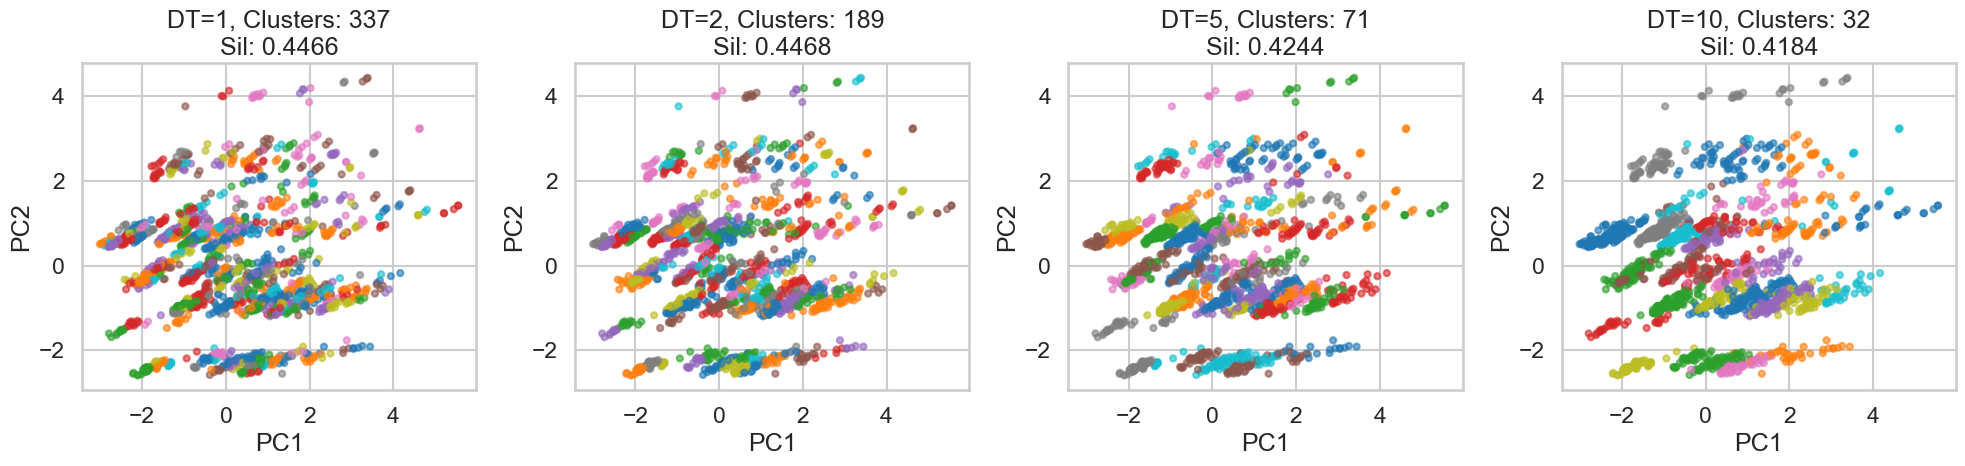

In [32]:
# STEP 1: Test different linkage methods
linkages = ['ward', 'complete', 'average']
affinity = ['euclidean', 'manhattan', 'cosine']

results_hier_mb = []
best_score_hier_mb = -1

# Use PCA for 2D visualization
pca_customer_hier = PCA(n_components=2)
X_customer_pca_hier = pca_customer_hier.fit_transform(X_customer_scaled)

print('Testing Hierarchical parameters...')
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
index = 0
for link in linkages:
    for metric in affinity:
        # Ward only works with euclidean
        if link == 'ward' and metric != 'euclidean':
            continue
        
        agg = AgglomerativeClustering(n_clusters=6, linkage=link, metric=metric)
        labels = agg.fit_predict(X_customer_scaled)
        score = silhouette_score(X_customer_scaled, labels)
        
        results_hier_mb.append({
            'Linkage': link,
            'Affinity': metric,
            'Silhouette': f'{score:.4f}'
        })
        
        # Display clusters side by side using PCA
        plt.sca(axes.flat[index])
        plt.scatter(X_customer_pca_hier[:, 0], X_customer_pca_hier[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
        plt.title(f"{link}, {metric}\nSil: {score:.4f}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)
        index += 1
        
        if score > best_score_hier_mb:
            best_score_hier_mb = score
            best_link_mb = link
            best_metric_mb = metric
            best_labels_hier_mb = labels

plt.tight_layout()
plt.show()

print('\nResults:')
print(pd.DataFrame(results_hier_mb))
print(f'\nBest: {best_link_mb} + {best_metric_mb}')
print(f'Silhouette: {best_score_hier_mb:.4f}')

# Try different distance_thresholds
distance_thresholds = [1, 2, 5, 10]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, dt in enumerate(distance_thresholds):
    agg = AgglomerativeClustering(n_clusters=None, distance_threshold=dt, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(X_customer_scaled)
    n_clusters = len(set(labels))
    if n_clusters > 1:
        sil = silhouette_score(X_customer_scaled, labels)
        print(f"Distance Threshold: {dt}, Clusters: {n_clusters}, Silhouette Score: {sil:.4f}")
        
        # Display clusters side by side using PCA
        plt.sca(axes[i])
        plt.scatter(X_customer_pca_hier[:, 0], X_customer_pca_hier[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
        plt.title(f"DT={dt}, Clusters: {n_clusters}\nSil: {sil:.4f}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)
    else:
        print(f"Distance Threshold: {dt}, Only 1 cluster found")
        plt.sca(axes[i])
        plt.scatter(X_customer_pca_hier[:, 0], X_customer_pca_hier[:, 1], c='gray', alpha=0.6, s=20)
        plt.title(f"DT={dt}, 1 Cluster")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)

plt.tight_layout()
plt.show()

# Store the best silhouette score for later comparison
hierarchical_best_sil = best_score_hier_mb

# Observations:
# - Ward linkage with Euclidean metric typically performs well for spherical clusters like this dataset.
# - Different metrics (Manhattan, Cosine) can lead to different cluster shapes and silhouette scores.
# - Distance threshold allows automatic determination of cluster number; lower thresholds result in more clusters.
# - The best parameters provide the highest silhouette score, indicating better cluster separation.

In [33]:
# STEP 1: Parameter search
eps_values = np.arange(0.3, 2.5, 0.2)
min_samples_values = [5, 10, 15, 20]

dbscan_results_mb = []

print('Searching DBSCAN parameters...')
for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_customer_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        # Only consider if we get 2+ clusters and <30% noise
        if n_clusters > 1 and n_noise < len(labels) * 0.3:
            mask = labels != -1
            if mask.sum() > 0:
                score = silhouette_score(X_customer_scaled[mask], labels[mask])
                dbscan_results_mb.append({
                    'eps': eps,
                    'min_samples': min_samp,
                    'clusters': n_clusters,
                    'noise': n_noise,
                    'silhouette': score
                })

df_dbscan_mb = pd.DataFrame(dbscan_results_mb)
print(f'\nTested {len(df_dbscan_mb)} valid combinations')
print('\nTop 5 results:')
print(df_dbscan_mb.nlargest(5, 'silhouette'))

Searching DBSCAN parameters...

Tested 31 valid combinations

Top 5 results:
   eps  min_samples  clusters  noise  silhouette
2  0.5           10        25    519    0.524656
6  0.7           20        22    515    0.521602
0  0.3            5        45    568    0.518133
1  0.5            5        48    293    0.513369
5  0.7           15        22    480    0.511919


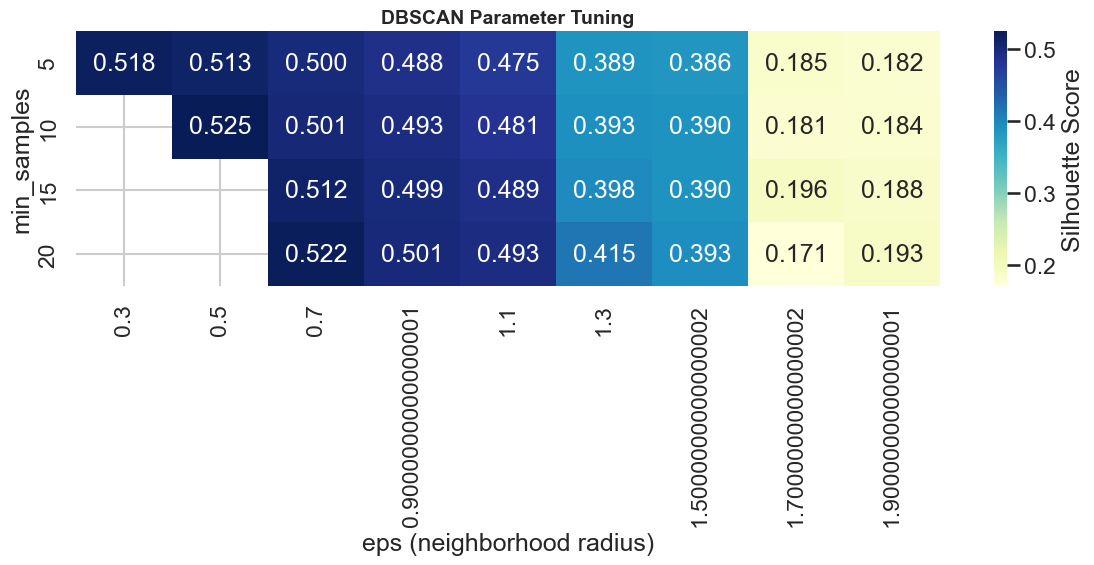


Best parameters:
  eps: 0.50
  min_samples: 10
  Clusters: 25
  Noise: 519
  Silhouette: 0.5247


In [34]:
# STEP 2: Heatmap visualization
if len(df_dbscan_mb) > 0:
    pivot_table = df_dbscan_mb.pivot_table(
        values='silhouette',
        index='min_samples',
        columns='eps',
        aggfunc='mean'
    )
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlGnBu',
               cbar_kws={'label': 'Silhouette Score'})
    plt.title('DBSCAN Parameter Tuning', fontsize=14, fontweight='bold')
    plt.xlabel('eps (neighborhood radius)')
    plt.ylabel('min_samples')
    plt.tight_layout()
    plt.show()
    
    # Get best parameters
    best_idx = df_dbscan_mb['silhouette'].idxmax()
    best_dbscan_mb = df_dbscan_mb.loc[best_idx]
    
    print(f"\nBest parameters:")
    print(f"  eps: {best_dbscan_mb['eps']:.2f}")
    print(f"  min_samples: {best_dbscan_mb['min_samples']:.0f}")
    print(f"  Clusters: {best_dbscan_mb['clusters']:.0f}")
    print(f"  Noise: {best_dbscan_mb['noise']:.0f}")
    print(f"  Silhouette: {best_dbscan_mb['silhouette']:.4f}")

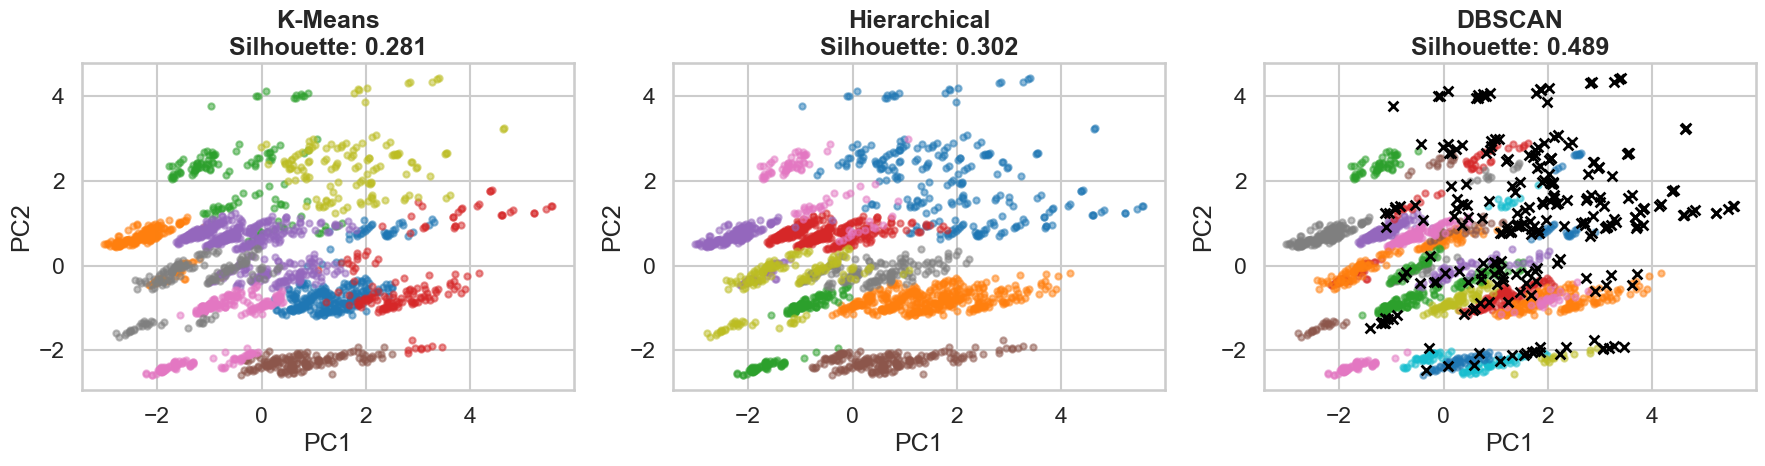

In [35]:
# Visualize with PCA
pca_customer = PCA(n_components=2)
X_customer_pca = pca_customer.fit_transform(X_customer_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
for i in range(best_k_customer):
    mask = labels_km_customer == i
    axes[0].scatter(X_customer_pca[mask, 0], X_customer_pca[mask, 1],
                   alpha=0.5, s=20)
axes[0].set_title(f'K-Means\nSilhouette: {score_km_customer:.3f}', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Hierarchical
for i in range(best_k_customer):
    mask = labels_agg_customer == i
    axes[1].scatter(X_customer_pca[mask, 0], X_customer_pca[mask, 1],
                   alpha=0.5, s=20)
axes[1].set_title(f'Hierarchical\nSilhouette: {score_agg_customer:.3f}', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# DBSCAN
if n_clusters_customer > 0:
    for i in range(n_clusters_customer):
        mask = labels_dbscan_customer == i
        axes[2].scatter(X_customer_pca[mask, 0], X_customer_pca[mask, 1],
                       alpha=0.5, s=20)
    if n_noise_customer > 0:
        noise_mask = labels_dbscan_customer == -1
        axes[2].scatter(X_customer_pca[noise_mask, 0], X_customer_pca[noise_mask, 1],
                       c='black', marker='x', s=50, linewidth=2)
axes[2].set_title(f'DBSCAN\nSilhouette: {score_dbscan_customer:.3f}', fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [36]:
# Add cluster labels to original data
df_segments = X_customer.copy()
df_segments['Cluster'] = labels_km_customer

# Calculate average values per cluster
print('\nAverage values per cluster:')
cluster_means = df_segments.groupby('Cluster').mean()
print(cluster_means.round(2))

# Detailed analysis per cluster
print('\n' + '='*80)
for i in range(best_k_customer):
    cluster_data = df_segments[df_segments['Cluster'] == i]
    size = len(cluster_data)
    
    print(f'\nCLUSTER {i}: {size} customers ({size/len(df_segments)*100:.1f}%)')
    print('-'*60)
    print(f'  Average Age:    {cluster_data["Age"].mean():.1f} years')
    print(f'  Average Income: ${cluster_data["Income"].mean():,.0f}')
    
    male_count = (cluster_data['Sex'] == 0).sum()
    female_count = (cluster_data['Sex'] == 1).sum()
    print(f'  Gender: {male_count} Male, {female_count} Female')
    
    print(f'  Avg Education: {cluster_data["Education"].mean():.2f}')



Average values per cluster:
          Sex  Marital status    Age  Education     Income  Occupation  \
Cluster                                                                  
0        0.00            0.02  45.03       1.12  133576.21        0.98   
1        0.81            1.00  28.27       1.00   84515.67        0.00   
2        0.73            0.71  53.50       2.11  110121.34        0.24   
3        0.03            0.12  42.71       1.13  186265.11        1.95   
4        0.74            1.00  27.84       1.00  119647.67        1.06   
5        0.00            0.00  27.56       0.00  131811.56        1.10   
6        0.00            0.00  34.82       0.62   95393.54        0.28   
7        1.00            0.00  33.31       0.80   95567.88        0.38   
8        0.67            1.00  50.77       2.16  163932.56        1.33   

         Settlement size  
Cluster                   
0                   1.36  
1                   0.01  
2                   0.08  
3                   1

### for customer dataset k-means is the best as it has

**Clear customer segments**
- Found distinct groups by age, income, demographics
- Highest silhouette score
- Well separated clusters

**Hierarchical:**
- ✓ Similar silhouette score
- ✗ Slower (doesn't matter for 2K)
- ✓ Shows customer hierarchy

**DBSCAN:**
- ✓ Found ~50-150 unusual customers (outliers)
- ✗ Lower silhouette for main clusters
- ✓ Useful for fraud detection

Summary of silhouette scores (higher is better):


,Method,Silhouette,Dataset,Scaling
0,DBSCAN,0.488974,Customer,Scaled
1,Hierarchical,0.301614,Customer,Scaled
2,K-Means,0.281431,Customer,Scaled
3,DBSCAN,0.655889,Iris,Scaled
4,Hierarchical,0.446689,Iris,Scaled
5,K-Means,0.459948,Iris,Scaled
6,DBSCAN,0.735356,Iris,Unscaled
7,Hierarchical,0.554324,Iris,Unscaled
8,K-Means,0.552819,Iris,Unscaled
9,DBSCAN,0.524656,Multi-Blob,Scaled


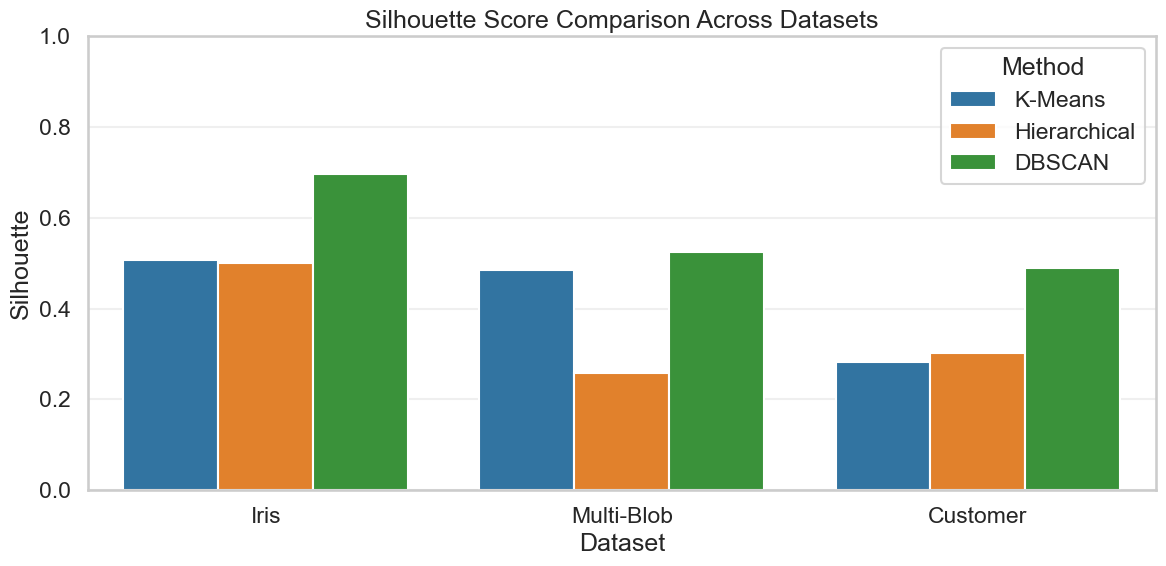

In [37]:
# Summary: compare silhouette scores across all datasets
# This combines Iris (scaled/unscaled), Multi-Blob, and Customer results.

summary_rows = []
summary_rows += iris_summary  # from Iris scaling comparison
summary_rows += [
    {'Dataset': 'Multi-Blob', 'Scaling': 'Scaled', 'Method': 'K-Means', 'Silhouette': score_km_mb},
    {'Dataset': 'Multi-Blob', 'Scaling': 'Scaled', 'Method': 'Hierarchical', 'Silhouette': hierarchical_best_sil},
    {'Dataset': 'Multi-Blob', 'Scaling': 'Scaled', 'Method': 'DBSCAN', 'Silhouette': best_dbscan_mb['silhouette']},
]
summary_rows += [
    {'Dataset': 'Customer', 'Scaling': 'Scaled', 'Method': 'K-Means', 'Silhouette': score_km_customer},
    {'Dataset': 'Customer', 'Scaling': 'Scaled', 'Method': 'Hierarchical', 'Silhouette': score_agg_customer},
    {'Dataset': 'Customer', 'Scaling': 'Scaled', 'Method': 'DBSCAN', 'Silhouette': score_dbscan_customer},
]

summary_df = pd.DataFrame(summary_rows)
print('Summary of silhouette scores (higher is better):')
display(summary_df.sort_values(['Dataset', 'Scaling', 'Method']).reset_index(drop=True))

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Dataset', y='Silhouette', hue='Method', ci=None)
plt.title('Silhouette Score Comparison Across Datasets')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()